{
  "base_param_overrides": {
    "A_detrap": 2.5,
    "A_detrap_attemptfreq": 1000000000000.0,
    "A_trap": 0.9,
    "A_trap_attemptfreq": 10000000000000.0,
    "B_detrap": 1.3,
    "B_detrap_attemptfreq": 1000000000000.0,
    "B_trap": 0.5,
    "B_trap_attemptfreq": 10000000000000.0,
    "C_detrap": 1.45,
    "C_detrap_attemptfreq": 1000000000000.0,
    "C_trap": 0.5,
    "C_trap_attemptfreq": 10000000000000.0,
    "D_detrap": 1.2,
    "D_detrap_attemptfreq": 1000000000000.0,
    "D_trap": 0.5,
    "D_trap_attemptfreq": 5000000000000.0
  },
  "case": {
    "anneal_C": 225.0,
    "anneal_s": 8000000.0,
    "fire_C": 650.0,
    "fire_s": 10.0,
    "name": "anneal_225",
    "threshold": 0.5
  },
  "expanded_params": {
    "A_detrap": 2.5,
    "A_detrap_attemptfreq": 1000000000000.0,
    "A_trap": 0.9,
    "A_trap_attemptfreq": 10000000000000.0,
    "B_detrap": 1.3,
    "B_detrap_attemptfreq": 1000000000000.0,
    "B_trap": 0.5,
    "B_trap_attemptfreq": 10000000000000.0,
    "C_detrap"

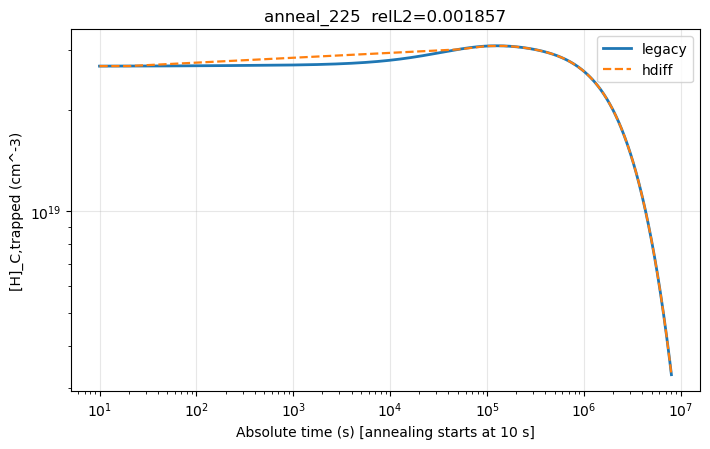

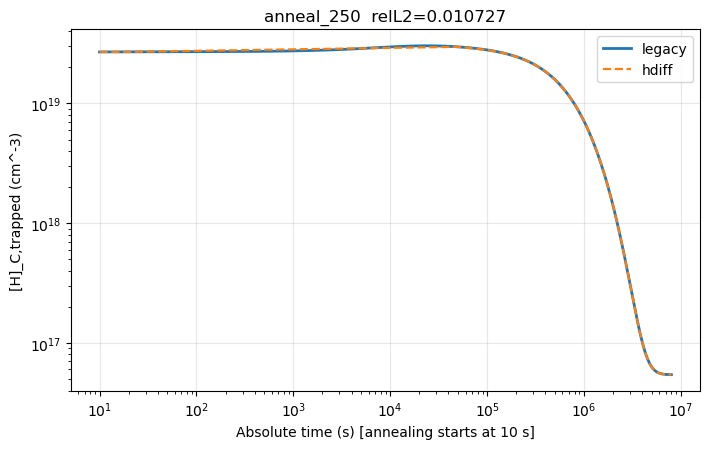

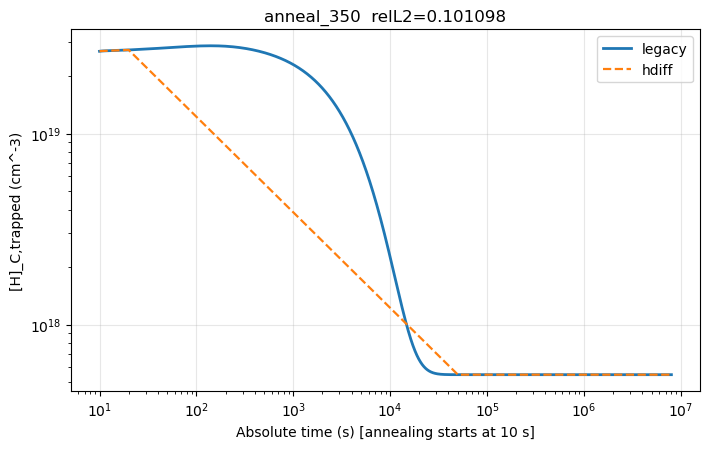

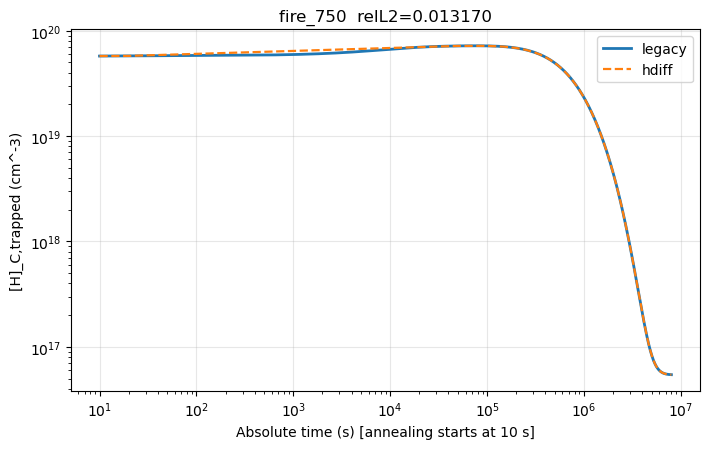

In [2]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "tests" else Path.cwd().resolve()
tests_dir = repo_root / "tests"
for p in (repo_root, tests_dir):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

from parity_harness import ParityCase, run_case, plot_case_result

cases = [
    ParityCase(name="anneal_225", fire_C=650.0, anneal_C=225.0, fire_s=10.0, anneal_s=8_000_000.0, threshold=0.50),
    ParityCase(name="anneal_250", fire_C=650.0, anneal_C=250.0, fire_s=10.0, anneal_s=8_000_000.0, threshold=0.50),
    ParityCase(name="anneal_350", fire_C=650.0, anneal_C=350.0, fire_s=10.0, anneal_s=8_000_000.0, threshold=0.50),
    ParityCase(name="fire_750", fire_C=750.0, anneal_C=250.0, fire_s=10.0, anneal_s=8_000_000.0, threshold=0.50),
]

#@agoga todo 
#I ran tests jupyter notebook and at later tmes things are looking much beter now. I'm still seeing that after my bootstrap segment of roughly 10s, there are not many data points until almost 10000 s which is not good for my plotting in general. Maybe this is coming from the variable dt picked by petsc in the new code being very large? Or maybe the number of snapshots we're taking is larger than previously?
#Also I would like to be able to turn on or off the print statments
results = []
for case in cases:
    result = run_case(case, verbose=True)
    print(f"{case.name}: rel_l2={result['rel_l2']:.6f} threshold={case.threshold:.3f}")
    fig, ax = plot_case_result(result)
    results.append((case, result))


=== case 1/4: anneal_225 ===
[legacy] 'anneal_225'  loading/running: 10:650C, 8000000:225C
[legacy] 'anneal_225' done: 897400 pts in 0.3s
[run_new_trace] 'anneal_225'  fire=650.0C/10.0s  anneal=225.0C/8000000.0s  base_out_dt=10.0s
  [sim] segment 'firing': 10s @ 650C
  [sim]   bootstrap done, t=10s, pts=100002
  [sim] segment 'firing' done: 100002 pts, 0.1s wall
  [sim] segment 'annealing': 8e+06s @ 225C
  [sim]   bootstrap done, t=20s, pts=200003
  [sim] segment 'annealing' done: 900001 pts, 1.2s wall
[run_new_trace] 'anneal_225' done: 1000002 pts in 1.7s
  → PASS  rel_l2=0.0000  rel_linf=0.0000  peak_t=3.148e+06s

=== case 2/4: anneal_250 ===
[legacy] 'anneal_250'  loading/running: 10:650C, 8000000:250C
[legacy] 'anneal_250' done: 906055 pts in 0.3s
[run_new_trace] 'anneal_250'  fire=650.0C/10.0s  anneal=250.0C/8000000.0s  base_out_dt=10.0s
  [sim] segment 'firing': 10s @ 650C
  [sim]   bootstrap done, t=10s, pts=100002
  [sim] segment 'firing' done: 100002 pts, 0.1s wall
  [sim] se

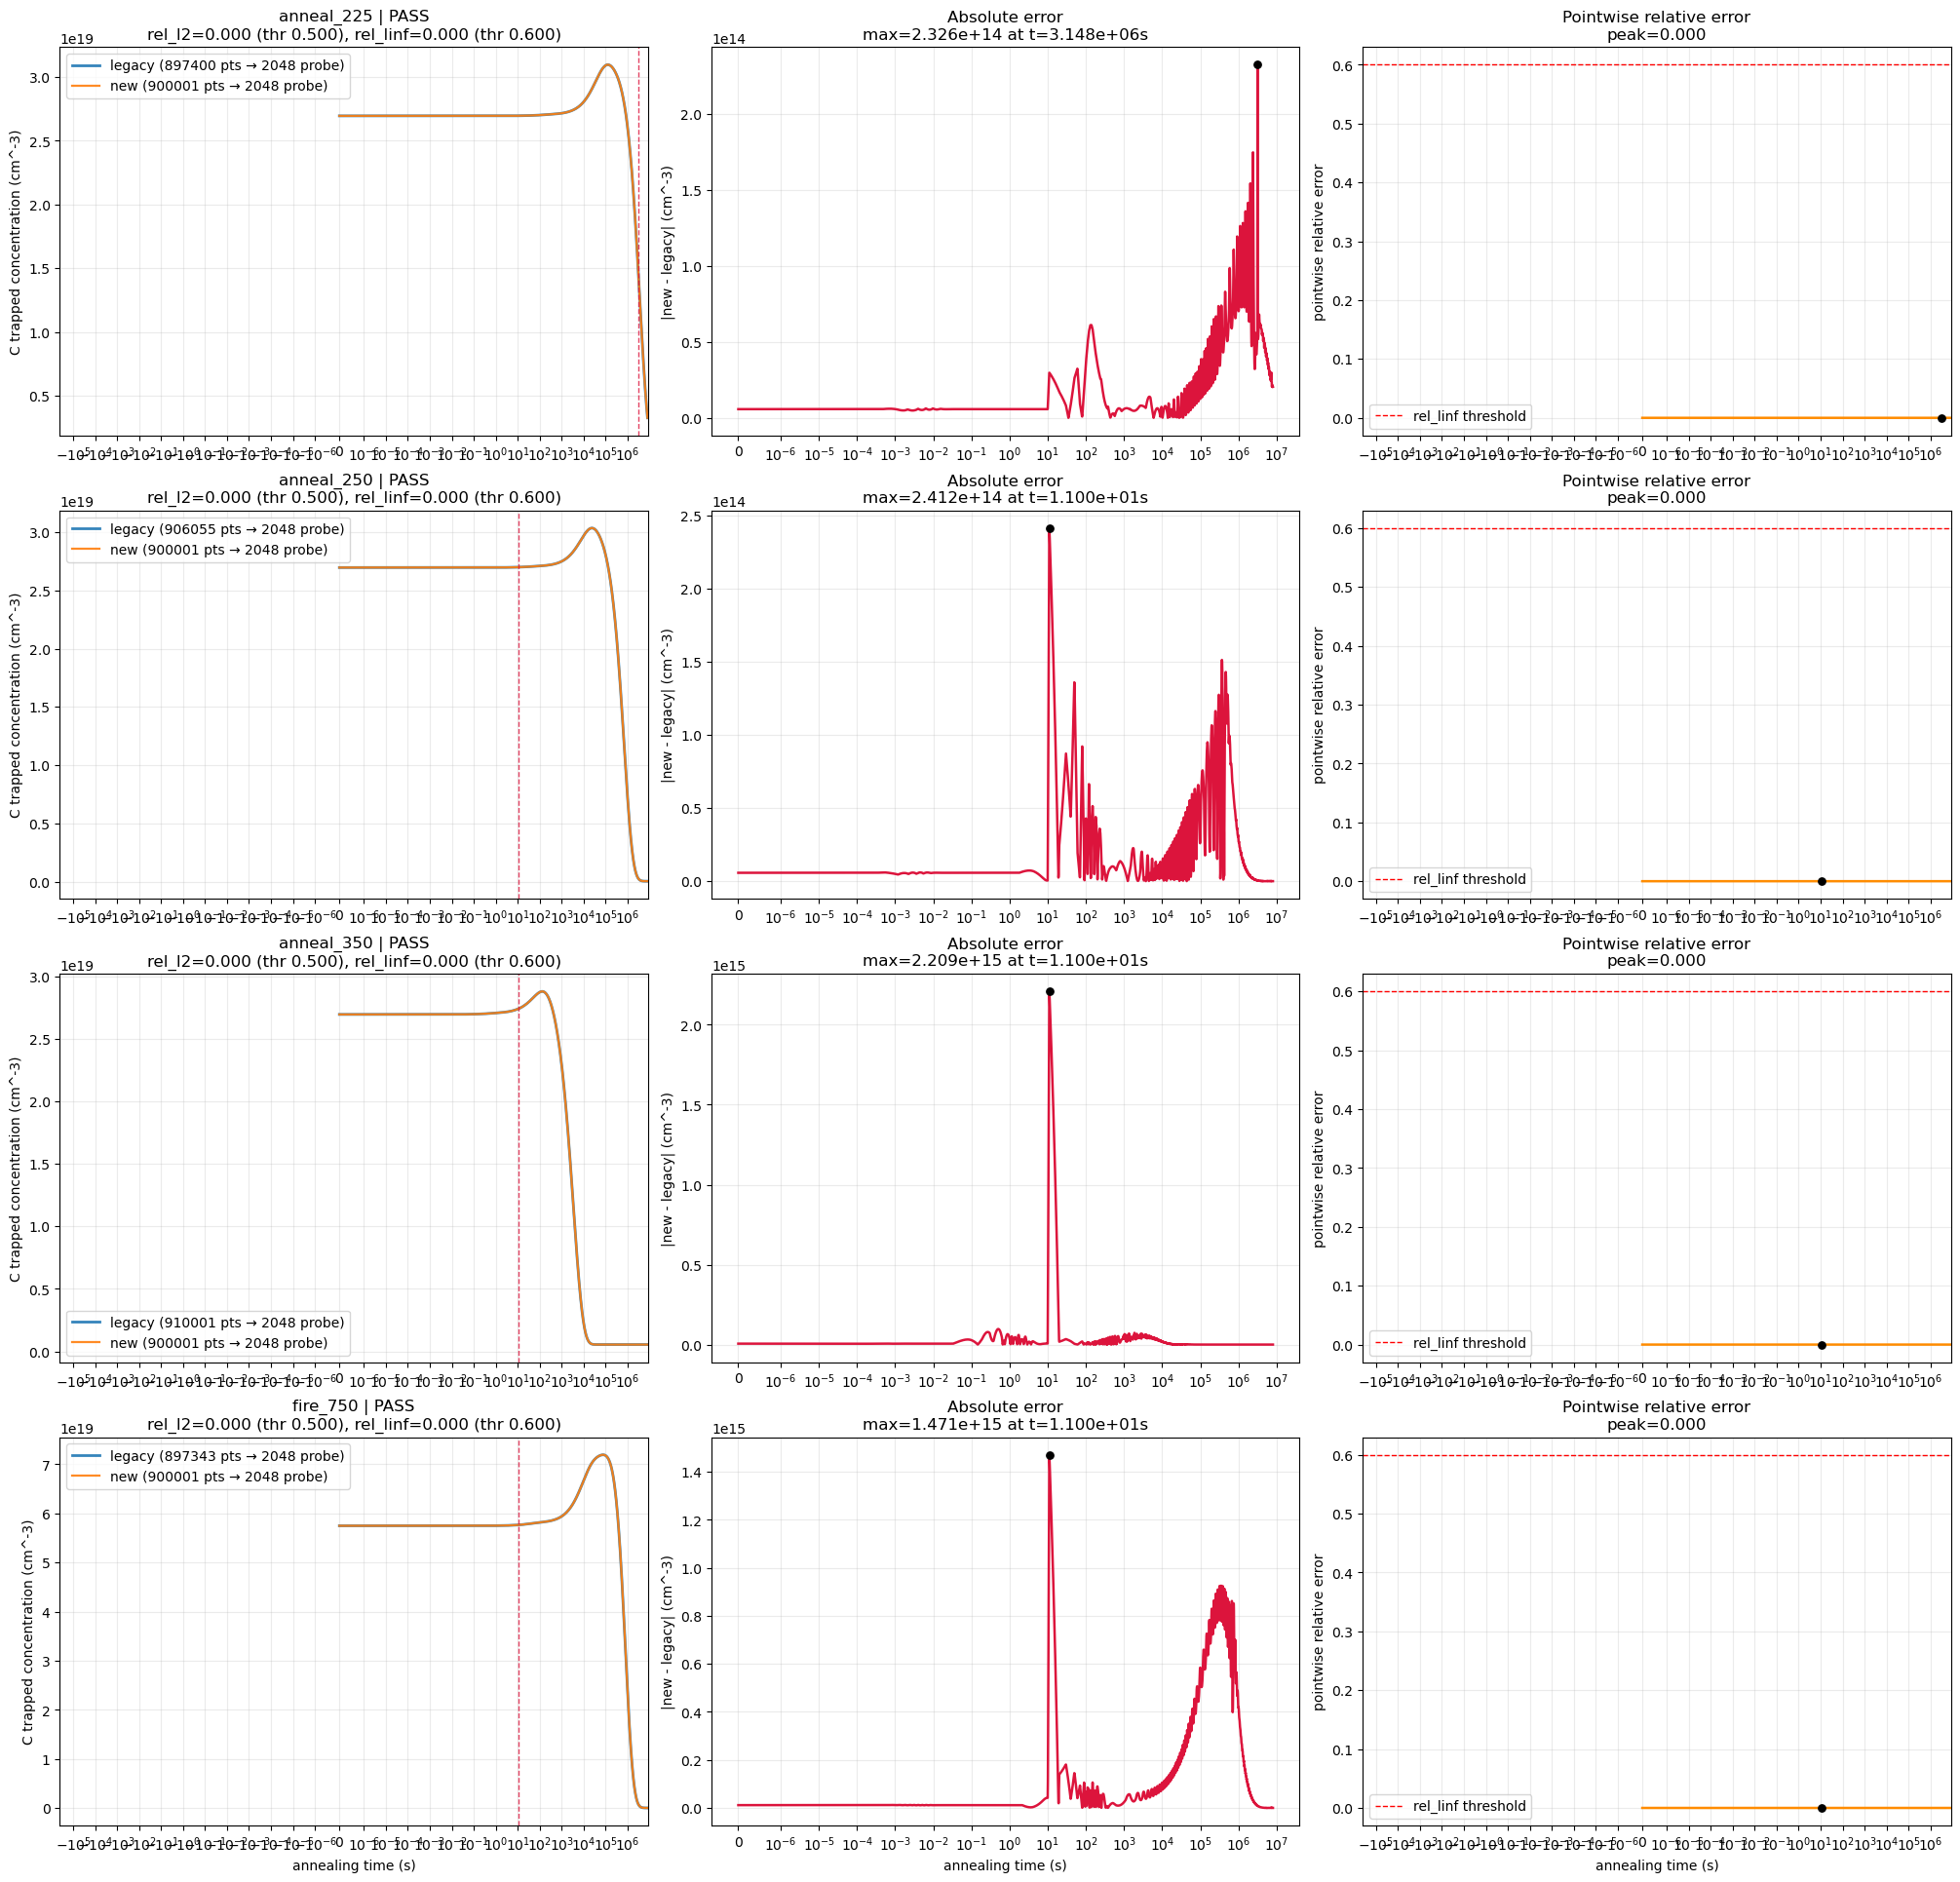


case         status     rel_l2   rel_linf        max_abs       peak_t_s    n_ref    n_new
anneal_225   PASS       0.0000     0.0000      2.326e+14      3.148e+06   897400   900001
anneal_250   PASS       0.0000     0.0000      2.412e+14      1.100e+01   906055   900001
anneal_350   PASS       0.0000     0.0001      2.209e+15      1.100e+01   910001   900001
fire_750     PASS       0.0000     0.0000      1.471e+15      1.100e+01   897343   900001

All live parity cases passed.


In [ ]:

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "tests" else cwd
tests_dir = repo_root / "tests"
legacy_dir = repo_root / "legacy"

for p in (repo_root, tests_dir, legacy_dir):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

try:
    from tests.parity_framework import (
        LegacyRuntimeBaselineSource,
        build_log_probe_grid,
        compare_traces,
        run_new_trace,
    )
    from tests.parity_cases import DEFAULT_CASES, DEFAULT_MEASURE
except ModuleNotFoundError:
    from parity_framework import (
        LegacyRuntimeBaselineSource,
        build_log_probe_grid,
        compare_traces,
        run_new_trace,
    )
    from parity_cases import DEFAULT_CASES, DEFAULT_MEASURE

VERBOSE = True  # set False to silence solver progress output

baseline = LegacyRuntimeBaselineSource(verbose=VERBOSE)
results = []

n_cases = len(DEFAULT_CASES)
fig, axes = plt.subplots(n_cases, 3, figsize=(20, 4.8 * n_cases), constrained_layout=True)
if n_cases == 1:
    axes = np.array([axes])

for row, case in enumerate(DEFAULT_CASES):
    print(f"\n=== case {row+1}/{n_cases}: {case.name} ===", flush=True)
    ref = baseline.get_trace(case, DEFAULT_MEASURE)
    sim = run_new_trace(case, DEFAULT_MEASURE, verbose=VERBOSE)

    probe = build_log_probe_grid(ref.t_s, n_points=2048)
    y_ref_probe = np.interp(probe, ref.t_s, ref.y)
    y_sim_probe = np.interp(probe, sim.t_s, sim.y)

    delta = y_sim_probe - y_ref_probe
    abs_delta = np.abs(delta)
    rel_point = abs_delta / np.maximum(np.abs(y_ref_probe), 1e-30)
    metrics = compare_traces(sim, ref, probe_t_s=probe)

    i_peak = int(np.argmax(abs_delta))
    t_peak = float(probe[i_peak])

    pass_l2 = metrics.rel_l2 < case.threshold_rel_l2
    pass_linf = metrics.rel_linf < case.threshold_rel_linf
    passed = pass_l2 and pass_linf

    results.append(
        {
            "name": case.name,
            "passed": passed,
            "rel_l2": metrics.rel_l2,
            "rel_linf": metrics.rel_linf,
            "max_abs": metrics.max_abs,
            "peak_t_s": t_peak,
            "peak_ref": float(y_ref_probe[i_peak]),
            "peak_new": float(y_sim_probe[i_peak]),
            "n_ref": int(ref.t_s.shape[0]),
            "n_new": int(sim.t_s.shape[0]),
        }
    )

    ax0, ax1, ax2 = axes[row]

    # Plot the probe grid (2048 pts) — not the full raw traces (can be 800k pts)
    ax0.plot(probe, y_ref_probe, label=f"legacy ({ref.t_s.shape[0]} pts → 2048 probe)", lw=2.0, alpha=0.9)
    ax0.plot(probe, y_sim_probe, label=f"new ({sim.t_s.shape[0]} pts → 2048 probe)", lw=1.6, alpha=0.9)
    ax0.axvline(t_peak, color="crimson", ls="--", lw=1.0, alpha=0.8)
    ax0.set_xscale("symlog", linthresh=1e-6)
    ax0.set_ylabel("C trapped concentration (cm^-3)")
    ax0.set_title(
        f"{case.name} | {'PASS' if passed else 'FAIL'}\n"
        f"rel_l2={metrics.rel_l2:.3f} (thr {case.threshold_rel_l2:.3f}), "
        f"rel_linf={metrics.rel_linf:.3f} (thr {case.threshold_rel_linf:.3f})"
    )
    ax0.grid(True, alpha=0.25)
    ax0.legend(loc="best")

    ax1.plot(probe, abs_delta, color="crimson", lw=1.8)
    ax1.scatter([t_peak], [abs_delta[i_peak]], color="black", s=28, zorder=3)
    ax1.set_xscale("symlog", linthresh=1e-6)
    ax1.set_ylabel("|new - legacy| (cm^-3)")
    ax1.set_title(f"Absolute error\nmax={metrics.max_abs:.3e} at t={t_peak:.3e}s")
    ax1.grid(True, alpha=0.25)

    ax2.plot(probe, rel_point, color="darkorange", lw=1.8)
    ax2.scatter([t_peak], [rel_point[i_peak]], color="black", s=28, zorder=3)
    ax2.axhline(case.threshold_rel_linf, color="red", ls="--", lw=1.0, label="rel_linf threshold")
    ax2.set_xscale("symlog", linthresh=1e-6)
    ax2.set_ylabel("pointwise relative error")
    ax2.set_title(f"Pointwise relative error\npeak={rel_point[i_peak]:.3f}")
    ax2.grid(True, alpha=0.25)
    ax2.legend(loc="best")

    print(f"  → {'PASS' if passed else 'FAIL'}  rel_l2={metrics.rel_l2:.4f}  rel_linf={metrics.rel_linf:.4f}  peak_t={t_peak:.3e}s", flush=True)

for ax in axes[-1]:
    ax.set_xlabel("annealing time (s)")

plt.show()

print(
    f"\n{'case':<12} {'status':<6} {'rel_l2':>10} {'rel_linf':>10} "
    f"{'max_abs':>14} {'peak_t_s':>14} {'n_ref':>8} {'n_new':>8}"
)
for r in results:
    print(
        f"{r['name']:<12} "
        f"{'PASS' if r['passed'] else 'FAIL':<6} "
        f"{r['rel_l2']:>10.4f} "
        f"{r['rel_linf']:>10.4f} "
        f"{r['max_abs']:>14.3e} "
        f"{r['peak_t_s']:>14.3e} "
        f"{r['n_ref']:>8d} "
        f"{r['n_new']:>8d}"
    )

failed = [r for r in results if not r["passed"]]
if failed:
    print("\nFailing cases:")
    for r in failed:
        print(
            f"- {r['name']}: rel_l2={r['rel_l2']:.6f}, "
            f"rel_linf={r['rel_linf']:.6f}, "
            f"max_abs={r['max_abs']:.3e}, "
            f"peak_t_s={r['peak_t_s']:.3e}, "
            f"legacy={r['peak_ref']:.3e}, "
            f"new={r['peak_new']:.3e}"
        )
else:
    print("\nAll live parity cases passed.")
